In [11]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image_dataset_from_directory



In [2]:
base_path = r"C:\Users\DIN REAKSA\Desktop\cat_dog_keras" 

# Define paths
training_dir = base_path + "/training_set"
testing_dir = base_path + "/test_set"

# Image parameters
img_size = (224, 224)  # Resize all images to 224x224
batch_size = 32  # 32 images per batch

In [3]:
train_dataset = image_dataset_from_directory(
    training_dir,
    seed=42,
    image_size=img_size,
    batch_size=batch_size,
    label_mode='binary'
)

print("Training dataset loaded successfully")
print(f"Number of batches: {len(train_dataset)}")

Found 8000 files belonging to 2 classes.
Training dataset loaded successfully
Number of batches: 250


In [6]:
validation_dataset = image_dataset_from_directory(
    training_dir,
    seed=42,
    image_size=img_size,
    batch_size=batch_size,
    label_mode='binary',
    validation_split=0.2,
    subset='validation'
)

print("Training dataset loaded successfully")
print(f"Training batches: {len(train_dataset)}")
print(f"Validation batches: {len(validation_dataset)}")

Found 8000 files belonging to 2 classes.
Using 1600 files for validation.
Training dataset loaded successfully
Training batches: 200
Validation batches: 50


In [7]:
test_dataset = image_dataset_from_directory(
    testing_dir,
    seed=42,
    image_size=img_size,
    batch_size=batch_size,
    label_mode='binary'
)

print("Test dataset loaded successfully")
print(f"Test batches: {len(test_dataset)}")

Found 2000 files belonging to 2 classes.
Test dataset loaded successfully
Test batches: 63


In [8]:
train_dataset = train_dataset.map(lambda x, y: (x / 255.0, y))
validation_dataset = validation_dataset.map(lambda x, y: (x / 255.0, y))
test_dataset = test_dataset.map(lambda x, y: (x / 255.0, y))

print("Data normalized (0-255 to 0-1)")

Data normalized (0-255 to 0-1)


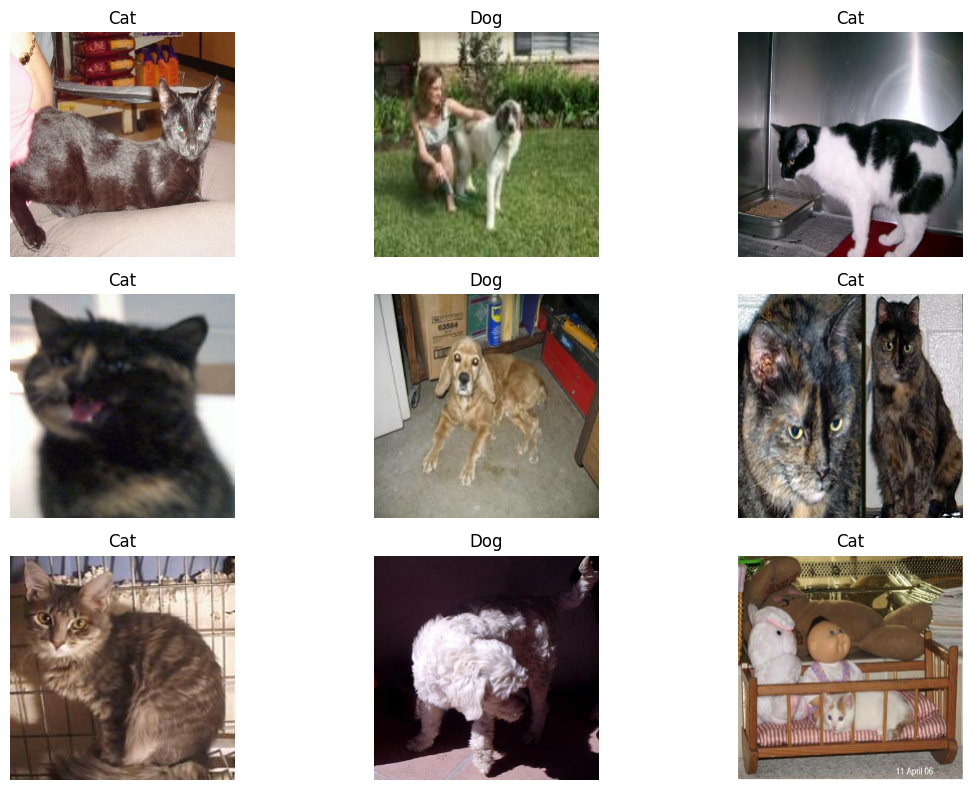

Batch shape: (32, 224, 224, 3)
Labels shape: (32, 1)


In [10]:
for images, labels in train_dataset.take(1):
    plt.figure(figsize=(12, 8))
    
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())
        label = "Dog" if labels[i] == 1 else "Cat"
        plt.title(label)
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()
    
    print(f"Batch shape: {images.shape}")
    print(f"Labels shape: {labels.shape}")

In [12]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.summary()

c:\Users\DIN REAKSA\Desktop\cat_dog_keras\venv_cnn\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully")

Model compiled successfully


In [14]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=10,
    verbose=1
)

print("Training completed")

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 164s 802ms/step - accuracy: 0.5152 - loss: 0.7034 - val_accuracy: 0.6269 - val_loss: 0.6655
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 208s 1s/step - accuracy: 0.6108 - loss: 0.6649 - val_accuracy: 0.6950 - val_loss: 0.6027
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 193s 962ms/step - accuracy: 0.6620 - loss: 0.6204 - val_accuracy: 0.7050 - val_loss: 0.5753
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 162s 809ms/step - accuracy: 0.7141 - loss: 0.5608 - val_accuracy: 0.7312 - val_loss: 0.5400
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 164s 820ms/step - accuracy: 0.7731 - loss: 0.4825 - val_accuracy: 0.7425 - val_loss: 0.5179
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 162s 808ms/step - accuracy: 0.8223 - loss: 0.3898 - val_accuracy: 0.7350 - val_loss: 0.5415
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 149s 745ms/step - accuracy: 0.8769 - loss: 0.2858 - val_accuracy: 0.7325 - val_loss: 0.5714
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 150s 748ms/step - accuracy: 0.9156 - lo

In [17]:
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np

test_loss, test_accuracy = model.evaluate(test_dataset, verbose=0)

all_predictions = []
all_labels = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)
    all_predictions.extend(predictions.flatten())
    all_labels.extend(labels.numpy())

all_predictions = np.array(all_predictions)
all_predictions_binary = (all_predictions > 0.5).astype(int)
all_labels = np.array(all_labels)

precision = precision_score(all_labels, all_predictions_binary)
recall = recall_score(all_labels, all_predictions_binary)
f1 = f1_score(all_labels, all_predictions_binary)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

print("\nConfusion Matrix:")
cm = confusion_matrix(all_labels, all_predictions_binary)
print(cm)

print("\nClassification Report:")
print(classification_report(all_labels, all_predictions_binary, target_names=['Cat', 'Dog']))

Test Accuracy: 74.85%
Test Loss: 0.8943
Precision: 0.7439
Recall: 0.7580
F1-Score: 0.7509

Confusion Matrix:
[[739 261]
 [242 758]]

Classification Report:
              precision    recall  f1-score   support

         Cat       0.75      0.74      0.75      1000
         Dog       0.74      0.76      0.75      1000

    accuracy                           0.75      2000
   macro avg       0.75      0.75      0.75      2000
weighted avg       0.75      0.75      0.75      2000

